# YOLO (bounding box) + tracking

In [28]:
import cv2
import numpy as np
from ultralytics import YOLO

# Load a detection model (could be your custom model trained on tennis ball)
model = YOLO("yolov8s.pt")  # or "best.pt" if you trained it

In [33]:
video_path = "tennis.mp4"
cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)

In [34]:
positions = []
times = []

# COCO class id for "sports ball" is 32
BALL_CLASS_ID = 32

while True:
    ret, frame = cap.read()
    if not ret:
        break

    t = cap.get(cv2.CAP_PROP_POS_MSEC) / 1000.0

    # Run YOLO on this frame
    results = model.predict(frame, conf=0.3, verbose=False)
    r = results[0]

    # Filter detections to keep only "sports ball"
    boxes = r.boxes
    if boxes is None or len(boxes) == 0:
        cv2.imshow("frame", frame)
        if cv2.waitKey(1) == 27:
            break
        continue

    # Convert to numpy for easy filtering
    cls = boxes.cls.cpu().numpy().astype(int)
    xyxy = boxes.xyxy.cpu().numpy()
    conf = boxes.conf.cpu().numpy()

    # keep only sports ball detections
    mask_ball = (cls == BALL_CLASS_ID)
    if not np.any(mask_ball):
        cv2.imshow("frame", frame)
        if cv2.waitKey(1) == 27:
            break
        continue

    ball_boxes = xyxy[mask_ball]
    ball_conf  = conf[mask_ball]

    # choose the most confident ball
    idx = np.argmax(ball_conf)
    x1, y1, x2, y2 = ball_boxes[idx]

    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0

    positions.append((cx, cy))
    times.append(t)

    # Draw bbox & center
    cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (0, 0, 255), 2)
    cv2.circle(frame, (int(cx), int(cy)), 4, (0, 255, 0), -1)

    cv2.imshow("frame", frame)
    if cv2.waitKey(1) == 27:
        break

cap.release()
cv2.destroyAllWindows()

In [35]:
import cv2
import numpy as np
from ultralytics import YOLO

# Load YOLO model
model = YOLO("yolov8s.pt")  # replace with best.pt if fine-tuned

video_path = "tennis.mp4"
cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)  # store fps now

BALL_CLASS_ID = 32  # COCO class id for "sports ball"
positions = []      # list of (x, y)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Detect objects
    results = model(frame, conf=0.3, verbose=False)
    r = results[0]
    boxes = r.boxes

    if boxes is not None and len(boxes) > 0:
        cls = boxes.cls.cpu().numpy().astype(int)
        xyxy = boxes.xyxy.cpu().numpy()
        conf = boxes.conf.cpu().numpy()

        # Keep only the tennis ball
        mask_ball = (cls == BALL_CLASS_ID)

        if np.any(mask_ball):
            ball_boxes = xyxy[mask_ball]
            ball_conf  = conf[mask_ball]

            # Most confident ball
            idx = np.argmax(ball_conf)
            x1, y1, x2, y2 = ball_boxes[idx]

            # Ball center
            cx = (x1 + x2) / 2.0
            cy = (y1 + y2) / 2.0

            positions.append((int(cx), int(cy)))

            # Draw bounding box and center
            cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (0, 0, 255), 2)
            cv2.circle(frame, (int(cx), int(cy)), 4, (0, 255, 0), -1)

    # -------- Draw trajectory line --------
    if len(positions) > 1:
        # Convert list to array for polyline
        pts = np.array(positions, dtype=np.int32)
        cv2.polylines(frame, [pts], isClosed=False, color=(255, 0, 0), thickness=2)

    cv2.imshow("YOLO Tennis Tracking", frame)
    if cv2.waitKey(1) == 27:   # ESC to exit
        break

cap.release()
cv2.destroyAllWindows()

print(f"FPS of video: {fps}")

FPS of video: 25.0


In [36]:
# Relative speed computation
# -----------------------------
positions_np = np.array(positions, dtype=np.float32)  # shape (N, 2)

speeds_px_per_s = []

for i in range(1, len(positions_np)):
    dist_px = np.linalg.norm(positions_np[i] - positions_np[i - 1])  # pixel displacement
    # assume constant fps; dt = 1/fps
    speed = dist_px * fps  # pixels per second
    speeds_px_per_s.append(speed)

speeds_px_per_s = np.array(speeds_px_per_s, dtype=np.float32)

if len(speeds_px_per_s) > 0:
    max_speed = float(speeds_px_per_s.max())
    mean_speed = float(speeds_px_per_s.mean())

    # normalized relative speeds in [0, 1]
    if max_speed > 0:
        speeds_rel = speeds_px_per_s / max_speed
    else:
        speeds_rel = speeds_px_per_s

    print(f"[YOLO] #positions: {len(positions_np)}")
    print(f"[YOLO] max relative speed (px/s): {max_speed:.2f}")
    print(f"[YOLO] mean relative speed (px/s): {mean_speed:.2f}")

    # if you want, you can save them to compare with other models later
    np.save("yolo_positions.npy", positions_np)
    np.save("yolo_speeds_px_per_s.npy", speeds_px_per_s)
    np.save("yolo_speeds_rel.npy", speeds_rel)
else:
    print("[YOLO] Not enough points to compute speed.")

[YOLO] #positions: 91
[YOLO] max relative speed (px/s): 6887.40
[YOLO] mean relative speed (px/s): 688.42


In [1]:
! pip install ultralytics segment-anything opencv-python matplotlib


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\acer\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [2]:
import cv2
import numpy as np
import torch
from ultralytics import YOLO
from segment_anything import sam_model_registry, SamPredictor

In [3]:
# Load YOLO (for ball bbox)

yolo = YOLO("yolov8s.pt")  # or your fine-tuned ball model
BALL_CLASS_ID = 32  # sports ball

In [5]:
# Load SAM model

sam_ckpt = "sam_vit_b_01ec64.pth"  # <- put your path here
sam = sam_model_registry["vit_b"](checkpoint=sam_ckpt)
device = "cuda" if torch.cuda.is_available() else "cpu"
sam.to(device)
predictor = SamPredictor(sam)

In [12]:
# Video

video_path = "tennis.mp4"
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
print("FPS:", fps)

positions = []  # centroids

torch.set_grad_enabled(False)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # 1) YOLO detection
    r = yolo(frame, conf=0.3, verbose=False)[0]
    boxes = r.boxes

    if boxes is not None and len(boxes) > 0:
        cls = boxes.cls.cpu().numpy().astype(int)
        xyxy = boxes.xyxy.cpu().numpy()
        conf = boxes.conf.cpu().numpy()
        
        mask_ball = (cls == BALL_CLASS_ID)
        if np.any(mask_ball):
            best_idx = np.argmax(conf[mask_ball])
            x1, y1, x2, y2 = xyxy[mask_ball][best_idx]
            
            # 2) SAM segmentation with YOLO box prompt
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            predictor.set_image(frame_rgb)
            box = np.array([[x1, y1, x2, y2]], dtype=np.float32)

            masks, scores, _ = predictor.predict(
                box=box,
                multimask_output=True
            )

            best_mask = masks[np.argmax(scores)].astype(np.uint8)

            # 3) Compute centroid
            ys, xs = np.where(best_mask == 1)
            if len(xs) > 0:
                cx, cy = int(xs.mean()), int(ys.mean())
                positions.append((cx, cy))

                # overlay mask
                overlay = frame.copy()
                overlay[best_mask == 1] = (0, 255, 0)
                frame = cv2.addWeighted(frame, 0.6, overlay, 0.4, 0)

                cv2.circle(frame, (cx, cy), 4, (0, 0, 255), -1)

    # draw trajectory
    if len(positions) > 1:
        pts = np.array(positions, dtype=np.int32)
        cv2.polylines(frame, [pts], isClosed=False, color=(255, 0, 0), thickness=2)

    cv2.imshow("SAM + YOLO Tennis Tracker", frame)
    if cv2.waitKey(1) == 27:
        break

cap.release()
cv2.destroyAllWindows()

FPS: 25.0


In [7]:
# Compute relative speed
# ---------------------------
positions_np = np.array(positions, dtype=np.float32)
speeds = []

for i in range(1, len(positions_np)):
    dist = np.linalg.norm(positions_np[i] - positions_np[i-1])
    speeds.append(dist * fps)

speeds = np.array(speeds, dtype=np.float32)
speeds_rel = speeds / speeds.max() if len(speeds) > 0 else np.array([])

np.save("sam_positions.npy", positions_np)
np.save("sam_speeds_rel.npy", speeds_rel)

print("[SAM] Tracking finished.")
print("Saved sam_positions.npy and sam_speeds_rel.npy")

[SAM] Tracking finished.
Saved sam_positions.npy and sam_speeds_rel.npy


In [8]:
! pip install opencv-python matplotlib
! pip install git+https://github.com/facebookresearch/segment-anything.git


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\acer\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git 'C:\Users\acer\AppData\Local\Temp\pip-req-build-_stbkslc'

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\acer\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip



  Cloning https://github.com/facebookresearch/segment-anything.git to c:\users\acer\appdata\local\temp\pip-req-build-_stbkslc
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36830 sha256=38aa6ea2443b276a4284a3d5e22395464567f5e3b27e3eeff1cf972c0fe9b188
  Stored in directory: C:\Users\acer\AppData\Local\Temp\pip-ephem-wheel-cache-ykldnaa9\wheels\29\82\ff\04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ---------------------------
# Load trajectories & speeds
# ---------------------------

# models = ["yolo", "yoloseg", "sam"]
models = ["yolo" , "sam"]

data = {}
for m in models:
    data[m] = {
        "pos": np.load(f"{m}_positions.npy", allow_pickle=True),
        "speeds": np.load(f"{m}_speeds_rel.npy", allow_pickle=True)
    }

In [9]:
# Metric 1 — Frame Coverage
print("=== FRAME COVERAGE ===")
for m in models:
    coverage = len(data[m]["pos"])
    print(f"{m.upper():7}: detected {coverage} frames")

=== FRAME COVERAGE ===
YOLO   : detected 91 frames
SAM    : detected 91 frames


In [10]:
# Metric 2 — Trajectory Smoothness
# variance of second difference

def trajectory_smoothness(positions):
    """
    Compute variance of second-order differences of the trajectory.
    Lower variance -> smoother -> better
    """
    pos = np.array(positions, dtype=np.float32)
    if len(pos) < 3:
        return np.nan
    second_diff = pos[2:] - 2 * pos[1:-1] + pos[:-2]
    return float(np.var(np.linalg.norm(second_diff, axis=1)))

print("\n=== TRAJECTORY SMOOTHNESS (lower is better) ===")
for m in models:
    sm = trajectory_smoothness(data[m]["pos"])
    print(f"{m.upper():7}: {sm:.6f}")


=== TRAJECTORY SMOOTHNESS (lower is better) ===
YOLO   : 4714.284180
SAM    : 4732.790527


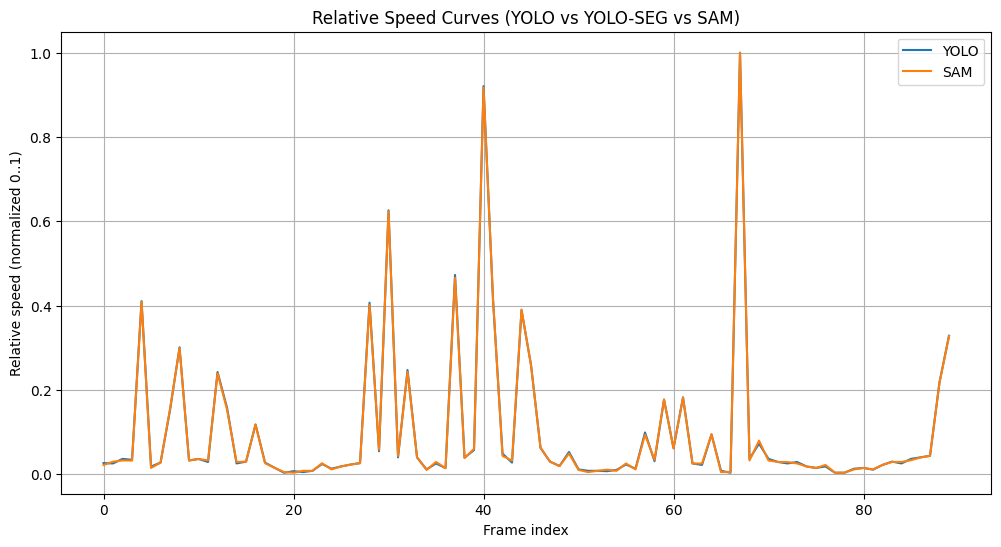

In [11]:
# Metric 3 — Plot Relative Speeds

plt.figure(figsize=(12,6))
for m in models:
    plt.plot(data[m]["speeds"], label=m.upper())
plt.title("Relative Speed Curves (YOLO vs YOLO-SEG vs SAM)")
plt.xlabel("Frame index")
plt.ylabel("Relative speed (normalized 0..1)")
plt.legend()
plt.grid(True)
plt.show()